In [1]:
!nvidia-smi

Sat Dec 27 12:12:39 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.94                 Driver Version: 560.94         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060      WDDM  |   00000000:09:00.0  On |                  N/A |
| 48%   47C    P2             42W /  170W |    2323MiB /  12288MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())


PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA device count: 1


In [9]:
# !pip install --upgrade torch torchvision torchaudio

In [11]:
import transformers
print(transformers.__version__)  # Should be 4.57.1

from transformers import SegformerForSemanticSegmentation
print("✅ SegFormer imported successfully")


C:\Users\Aniruddha\anaconda3\envs\env-vikash\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


4.57.1
✅ SegFormer imported successfully


In [ ]:

import logging

logging.getLogger("tifffile").setLevel(logging.ERROR)


In [ ]:


import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import tifffile as tiff
from tqdm import tqdm
import matplotlib.pyplot as plt
from transformers import SegformerForSemanticSegmentation



In [ ]:

import os


extract_dir = "D:/Vikash/Dataset"
# Paths after extraction
images_path = os.path.join(extract_dir, "Image")
masks_path  = os.path.join(extract_dir, "Mask")
swir_path = os.path.join(extract_dir, "SWIR")
dem_path = os.path.join(extract_dir, "DEM")
build_path = os.path.join(extract_dir, "Build")
road_path = os.path.join(extract_dir, "Road")
# Quick check
print("\nSample files:")
print("Images:", os.listdir(images_path)[:5])
print("Masks:", os.listdir(masks_path)[:5])
print("Swir:", os.listdir(swir_path)[:5])
print("Dem:", os.listdir(dem_path)[:5])
print("Build-up:", os.listdir(build_path)[:5])
print("Road:", os.listdir(road_path)[:5])



Sample files:
Images: ['Image_0001.tif', 'Image_0002.tif', 'Image_0003.tif', 'Image_0004.tif', 'Image_0005.tif']
Masks: ['Mask_0001.tif', 'Mask_0002.tif', 'Mask_0003.tif', 'Mask_0004.tif', 'Mask_0005.tif']
Swir: ['Swir_0001.tif', 'Swir_0002.tif', 'Swir_0003.tif', 'Swir_0004.tif', 'Swir_0005.tif']
Dem: ['Dem_0001.tif', 'Dem_0002.tif', 'Dem_0003.tif', 'Dem_0004.tif', 'Dem_0005.tif']
Build-up: ['built_0001.tif', 'built_0002.tif', 'built_0003.tif', 'built_0004.tif', 'built_0005.tif']
Road: ['Road_0001.tif', 'Road_0002.tif', 'Road_0003.tif', 'Road_0004.tif', 'Road_0005.tif']


In [ ]:

import os
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
import tifffile as tiff


class MultiModalSegDataset(Dataset):
    def __init__(self, images_dir, swir_dir, dem_dir, build_dir, road_dir,
                 masks_dir,
                 crop_size=256, num_classes=5, normalize=True):

        self.images_dir = images_dir
        self.swir_dir   = swir_dir
        self.dem_dir    = dem_dir
        self.build_dir  = build_dir
        self.road_dir   = road_dir
        self.masks_dir  = masks_dir

        self.crop_size  = crop_size
        self.num_classes = num_classes
        self.normalize  = normalize

        # -------------------------
        # Read filenames
        # -------------------------
        self.image_files = sorted(os.listdir(images_dir))
        self.swir_files  = sorted(os.listdir(swir_dir))
        self.dem_files   = sorted(os.listdir(dem_dir))
        self.build_files = sorted(os.listdir(build_dir))
        self.road_files  = sorted(os.listdir(road_dir))
        self.mask_files  = sorted(os.listdir(masks_dir))

        # -------------------------
        # Check counts
        # -------------------------
        assert len(self.image_files) == len(self.swir_files) == len(self.dem_files) == len(self.build_files) == len(self.road_files), \
            "❌ File mismatch between modalities."

        assert len(self.mask_files) == len(self.image_files), \
            "❌ Mask count does not match image count (pseudo removed)."

        # -------------------------
        # Create 4-crop indices
        # -------------------------
        self.samples = []
        for idx in range(len(self.image_files)):
            for crop_idx in range(4):
                self.samples.append((idx, crop_idx))

        # RGB normalization
        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        self.std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


    # ---------- Utility functions ----------
    def _read_tiff_or_img(self, path):
        if path.lower().endswith(('.tif', '.tiff')):
            return tiff.imread(path)
        return np.array(Image.open(path))

    def _normalize_to_01(self, arr):
        arr = arr.astype(np.float32)
        return (arr - np.nanmin(arr)) / (np.nanmax(arr) - np.nanmin(arr) + 1e-8)

    def _read_rgb(self, path):
        img = self._read_tiff_or_img(path)
        if img.ndim == 2:
            img = np.stack([img]*3, axis=-1)
        elif img.ndim == 3 and img.shape[0] == 3:
            img = np.transpose(img, (1,2,0))
        img = self._normalize_to_01(img)
        return img

    def _read_swir(self, path):
        arr = self._read_tiff_or_img(path)
        if arr.ndim == 2:
            arr = np.expand_dims(arr, -1)
        if arr.ndim == 3 and arr.shape[-1] > 3:
            arr = arr[..., :3]
        arr = self._normalize_to_01(arr)
        return np.transpose(arr, (2,0,1))

    def _read_single(self, path):
        arr = self._read_tiff_or_img(path)
        arr = self._normalize_to_01(arr.squeeze())
        return np.expand_dims(arr, 0)

    def _read_mask(self, path):
        mask = self._read_tiff_or_img(path)
        if mask.ndim == 3:
            mask = mask[:, :, 0]
        return mask.astype(np.int64)


    # ---------- Crop coordinates ----------
    def _get_crop_coords(self, H, W, crop_idx):
        half_H = H // 2
        half_W = W // 2
        if crop_idx == 0: return 0, 0
        if crop_idx == 1: return 0, W - self.crop_size
        if crop_idx == 2: return H - self.crop_size, 0
        return H - self.crop_size, W - self.crop_size


    # ---------- MAIN GETITEM ----------
    def __getitem__(self, index):
        img_idx, crop_idx = self.samples[index]

        img_path   = os.path.join(self.images_dir, self.image_files[img_idx])
        swir_path  = os.path.join(self.swir_dir,   self.swir_files[img_idx])
        dem_path   = os.path.join(self.dem_dir,    self.dem_files[img_idx])
        build_path = os.path.join(self.build_dir,  self.build_files[img_idx])
        road_path = os.path.join(self.road_dir,  self.road_files[img_idx])
        mask_path  = os.path.join(self.masks_dir,  self.mask_files[img_idx])  # <-- always real GT mask

        # Read all files
        image = self._read_rgb(img_path)
        swir  = self._read_swir(swir_path)
        dem   = self._read_single(dem_path)
        build = self._read_single(build_path)
        road = self._read_single(road_path)
        mask  = self._read_mask(mask_path)

        # Crop
        H, W = mask.shape
        top, left = self._get_crop_coords(H, W, crop_idx)
        bottom, right = top + self.crop_size, left + self.crop_size

        image = np.transpose(image, (2,0,1))[:, top:bottom, left:right]
        swir  = swir[:, top:bottom, left:right]
        dem   = dem[:, top:bottom, left:right]
        build = build[:, top:bottom, left:right]
        road = road[:, top:bottom, left:right]
        mask  = mask[top:bottom, left:right]

        # Normalize RGB
        if self.normalize:
            for c in range(3):
                image[c] = (image[c] - self.mean[c]) / self.std[c]

        # Convert to Torch
        image = torch.tensor(image, dtype=torch.float32)
        swir  = torch.tensor(swir, dtype=torch.float32)
        dem   = torch.tensor(dem, dtype=torch.float32)
        build = torch.tensor(build, dtype=torch.float32)
        road = torch.tensor(road, dtype=torch.float32)
        mask  = torch.tensor(mask, dtype=torch.long)

        mask[mask >= self.num_classes] = self.num_classes - 1

        return image, swir, dem, build, road, mask


    def __len__(self):
        return len(self.samples)


In [16]:
# ================================
# Initialize Dataset (NO pseudo labels)
# ================================
IMAGES_DIR = os.path.join(extract_dir, "Image")
MASKS_DIR  = os.path.join(extract_dir, "Mask")
SWIR_DIR   = os.path.join(extract_dir, "SWIR")
DEM_DIR    = os.path.join(extract_dir, "DEM")
BUILD_DIR  = os.path.join(extract_dir, "Build")
ROAD_DIR    = os.path.join(extract_dir, "Road")

# No Pseudo directory needed now

full_dataset = MultiModalSegDataset(
    images_dir=IMAGES_DIR,
    swir_dir=SWIR_DIR,
    dem_dir=DEM_DIR,
    build_dir=BUILD_DIR,
    road_dir=ROAD_DIR,
    masks_dir=MASKS_DIR,    # Only real masks
    crop_size=256,
    num_classes=5,
    normalize=True
)

print("✅ Dataset loaded successfully!")
print("Total samples:", len(full_dataset))

# Quick check
image, swir, dem, build, road, mask = full_dataset[0]
print("RGB shape:", image.shape)
print("SWIR shape:", swir.shape)
print("DEM shape:", dem.shape)
print("Build shape:", build.shape)
print("Road shape:",road.shape)
print("Mask shape:", mask.shape)


✅ Dataset loaded successfully!
Total samples: 4296
RGB shape: torch.Size([3, 256, 256])
SWIR shape: torch.Size([3, 256, 256])
DEM shape: torch.Size([1, 256, 256])
Build shape: torch.Size([1, 256, 256])
Road shape: torch.Size([1, 256, 256])
Mask shape: torch.Size([256, 256])


In [17]:
# ================================
# DataLoader + Train/Val Split
# NO pseudo-labelled data
# ================================
from torch.utils.data import DataLoader, random_split
import torch

# -------------------------------
# Dataset paths
# -------------------------------
IMAGES_DIR = "D:/Vikash/Dataset/Image"
MASKS_DIR  = "D:/Vikash/Dataset/Mask"
SWIR_DIR   = "D:/Vikash/Dataset/SWIR"
DEM_DIR    = "D:/Vikash/Dataset/DEM"
BUILD_DIR  = "D:/Vikash/Dataset/Build"
ROAD_DIR   = "D:/Vikash/Dataset/Road"

# -------------------------------
# Initialize dataset (NO pseudo_dir)
# -------------------------------
full_dataset = MultiModalSegDataset(
    images_dir=IMAGES_DIR,
    swir_dir=SWIR_DIR,
    dem_dir=DEM_DIR,
    build_dir=BUILD_DIR,
    road_dir=ROAD_DIR,
    masks_dir=MASKS_DIR,
    crop_size=256,
    num_classes=5,
    normalize=True
)

# -------------------------------
# Train/Validation split
# -------------------------------
seed = 42
torch.manual_seed(seed)

train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

# -------------------------------
# Custom Collate Function
# -------------------------------
def multimodal_collate_fn(batch):
    image_batch = torch.stack([x[0] for x in batch])
    swir_batch  = torch.stack([x[1] for x in batch])
    dem_batch   = torch.stack([x[2] for x in batch])
    build_batch = torch.stack([x[3] for x in batch])
    road_batch  = torch.stack([x[4] for x in batch])
    mask_batch  = torch.stack([x[5] for x in batch])
    return image_batch, swir_batch, dem_batch, build_batch, road_batch, mask_batch

# -------------------------------
# DataLoaders
# -------------------------------
BATCH_SIZE  = 1
NUM_WORKERS = 0  # keep 0 on Colab

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=multimodal_collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=multimodal_collate_fn
)

# -------------------------------
# Sanity check
# -------------------------------
img_b, swir_b, dem_b, build_b, road_b, mask_b = next(iter(train_loader))

print("✔ Shapes:")
print("Image:", img_b.shape)
print("SWIR :", swir_b.shape)
print("DEM  :", dem_b.shape)
print("BUILD:", build_b.shape)
print("Road:",  road_b.shape)
print("Mask :", mask_b.shape)


✔ Shapes:
Image: torch.Size([1, 3, 256, 256])
SWIR : torch.Size([1, 3, 256, 256])
DEM  : torch.Size([1, 1, 256, 256])
BUILD: torch.Size([1, 1, 256, 256])
Road: torch.Size([1, 1, 256, 256])
Mask : torch.Size([1, 256, 256])


cheching the sequence

In [ ]:
# ==========================================================
# MultiModal SegFormer (shared SegFormer-B2 encoder)
# Cross-Attention Fusion + Attention-Guided Upsampling (CNN)
# Inputs / outputs / variable names preserved
# ==========================================================
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import SegformerModel


# --------------------------
# Helpers
# --------------------------
def tokens_to_map(x):
    """
    Convert transformer token output (B, N, C) to map (B, C, H, W),
    assuming tokens are arranged as square grid.
    """
    if x.ndim == 3:
        B, N, C = x.shape
        H = W = int(math.sqrt(N))
        return x.transpose(1, 2).reshape(B, C, H, W)
    elif x.ndim == 4:
        return x
    else:
        raise ValueError("Unexpected feature shape: ", x.shape)


# --------------------------
# Cross-Attention Fusion Block (semantic, global)
# --------------------------
class CrossAttentionFusion(nn.Module):
    def __init__(self, dim, num_heads=8):
        super().__init__()
        self.attn_swir = nn.MultiheadAttention(dim, num_heads)
        self.attn_dem = nn.MultiheadAttention(dim, num_heads)
        self.attn_build = nn.MultiheadAttention(dim, num_heads)
        self.attn_road = nn.MultiheadAttention(dim, num_heads)

        self.alpha = nn.Parameter(torch.tensor([0.25, 0.25, 0.25, 0.25]))
        self.norm = nn.LayerNorm(dim)

    def forward(self, fcc_map, swir_map, dem_map, build_map, road_map):
        """
        All inputs: [B, C, H, W]
        """
        B, C, H, W = fcc_map.shape

        q = fcc_map.flatten(2).permute(2, 0, 1)

        def attend(attn, x):
            k = x.flatten(2).permute(2, 0, 1)
            v, _ = attn(q, k, k)
            return v

        f_s = attend(self.attn_swir, swir_map)
        f_d = attend(self.attn_dem, dem_map)
        f_b = attend(self.attn_build, build_map)
        f_r = attend(self.attn_road, road_map)

        fused = q + (
            self.alpha[0] * f_s +
            self.alpha[1] * f_d +
            self.alpha[2] * f_b +
            self.alpha[3] * f_r
        )

        fused = self.norm(fused)
        fused = fused.permute(1, 2, 0).view(B, C, H, W)
        return fused


# --------------------------
# Attention-Guided Upsampling (CNN, edge-preserving)
# --------------------------
class AttentionGuidedUpsample(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.conv_low = nn.Conv2d(dim, dim, kernel_size=1)
        self.conv_high = nn.Conv2d(dim, dim, kernel_size=1)

        self.psi = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Conv2d(dim, 1, kernel_size=1),
            nn.Sigmoid()
        )

        self.refine = nn.Conv2d(dim, dim, kernel_size=3, padding=1)

    def forward(self, low, high):
        """
        low:  [B, C, H_low, W_low]   (decoder, semantic)
        high: [B, C, H_high, W_high] (skip, spatial)
        """
        low_up = F.interpolate(low, size=high.shape[2:], mode="bilinear", align_corners=False)

        g = self.conv_low(low_up)
        x = self.conv_high(high)

        attn = self.psi(g + x)      # spatial attention
        out = high * attn           # gate skip features
        out = self.refine(out + low_up)

        return out


# --------------------------
# Main model
# --------------------------
class MultiModalSegFormerShared(nn.Module):
    def __init__(self, num_classes=5, decoder_dim=512, attn_heads=8):
        super().__init__()

        # Shared SegFormer encoder (FCC only)
        self.encoder = SegformerModel.from_pretrained(
            "nvidia/segformer-b2-finetuned-ade-512-512",
            output_hidden_states=True
        )
        embed_dims = self.encoder.config.hidden_sizes  # [64,128,320,512]

        # Lightweight projection heads
        def make_proj(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            )

        self.swir_proj = nn.ModuleList([make_proj(3, d) for d in embed_dims[:3]])
        self.dem_proj = nn.ModuleList([make_proj(1, d) for d in embed_dims[:3]])
        self.build_proj = nn.ModuleList([make_proj(1, d) for d in embed_dims[:3]])
        self.road_proj = nn.ModuleList([make_proj(1, d) for d in embed_dims[:3]])

        # Cross-attention fusion blocks
        self.cross1 = CrossAttentionFusion(embed_dims[0], attn_heads)
        self.cross2 = CrossAttentionFusion(embed_dims[1], attn_heads)
        self.cross3 = CrossAttentionFusion(embed_dims[2], attn_heads)

        # Decoder projections
        self.linear_c1 = nn.Conv2d(embed_dims[0], decoder_dim, 1)
        self.linear_c2 = nn.Conv2d(embed_dims[1], decoder_dim, 1)
        self.linear_c3 = nn.Conv2d(embed_dims[2], decoder_dim, 1)
        self.linear_c4 = nn.Conv2d(embed_dims[3], decoder_dim, 1)

        # Attention-guided upsampling decoder
        self.attn_up3 = AttentionGuidedUpsample(decoder_dim)
        self.attn_up2 = AttentionGuidedUpsample(decoder_dim)
        self.attn_up1 = AttentionGuidedUpsample(decoder_dim)

        self.dropout = nn.Dropout2d(0.1)
        self.classifier = nn.Conv2d(decoder_dim, num_classes, 1)

    def forward(self, fcc, swir, dem, build, road):
        """
        Inputs preserved:
        fcc:   [B, 3, H, W]
        swir:  [B, 3, H, W]
        dem:   [B, 1, H, W]
        build: [B, 1, H, W]
        road:  [B, 1, H, W]
        """
        # Encoder
        enc = self.encoder(pixel_values=fcc, return_dict=True)
        c1, c2, c3, c4 = [tokens_to_map(h) for h in enc.hidden_states]

        size1 = c1.shape[2:]
        size2 = c2.shape[2:]
        size3 = c3.shape[2:]

        # Project auxiliary modalities
        swir_feats, dem_feats, build_feats, road_feats = [], [], [], []

        for i in range(3):
            swir_feats.append(F.interpolate(self.swir_proj[i](swir), size=(size1 if i==0 else size2 if i==1 else size3)))
            dem_feats.append(F.interpolate(self.dem_proj[i](dem), size=(size1 if i==0 else size2 if i==1 else size3)))
            build_feats.append(F.interpolate(self.build_proj[i](build), size=(size1 if i==0 else size2 if i==1 else size3)))
            road_feats.append(F.interpolate(self.road_proj[i](road), size=(size1 if i==0 else size2 if i==1 else size3)))

        # Cross-attention fusion
        c1 = self.cross1(c1, swir_feats[0], dem_feats[0], build_feats[0], road_feats[0])
        c2 = self.cross2(c2, swir_feats[1], dem_feats[1], build_feats[1], road_feats[1])
        c3 = self.cross3(c3, swir_feats[2], dem_feats[2], build_feats[2], road_feats[2])

        # Decoder
        p1 = self.linear_c1(c1)
        p2 = self.linear_c2(c2)
        p3 = self.linear_c3(c3)
        p4 = self.linear_c4(c4)

        x = self.attn_up3(p4, p3)
        x = self.attn_up2(x, p2)
        x = self.attn_up1(x, p1)

        x = self.dropout(x)
        logits = self.classifier(x)
        logits = F.interpolate(logits, size=fcc.shape[2:], mode="bilinear", align_corners=False)

        return logits


In [21]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Total GPUs:", torch.cuda.device_count())
else:
    print("No GPU detected by PyTorch.")


PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA version: 12.4
GPU name: NVIDIA GeForce RTX 3060
Total GPUs: 1


In [22]:
# Optional quick test – NOT required for training
import torch, gc
gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

model = MultiModalSegFormerShared(num_classes=5, decoder_dim=256).to(device)
model.eval()

fcc, swir, dem, build, road, mask = next(iter(train_loader))

fcc   = fcc[:1].to(device)
swir  = swir[:1].to(device)
dem   = dem[:1].to(device)
build = build[:1].to(device)
road  = road[:1].to(device)
mask  = mask[:1].to(device)

print("FCC:", fcc.shape)
print("SWIR:", swir.shape)
print("DEM:", dem.shape)
print("BUILD:", build.shape)
print("ROAD:", road.shape)
print("MASK:", mask.shape)


Using: cuda
FCC: torch.Size([1, 3, 256, 256])
SWIR: torch.Size([1, 3, 256, 256])
DEM: torch.Size([1, 1, 256, 256])
BUILD: torch.Size([1, 1, 256, 256])
ROAD: torch.Size([1, 1, 256, 256])
MASK: torch.Size([1, 256, 256])


In [23]:

model.to(device)
from torch import optim

# Optim & training settings
optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
num_epochs = 20



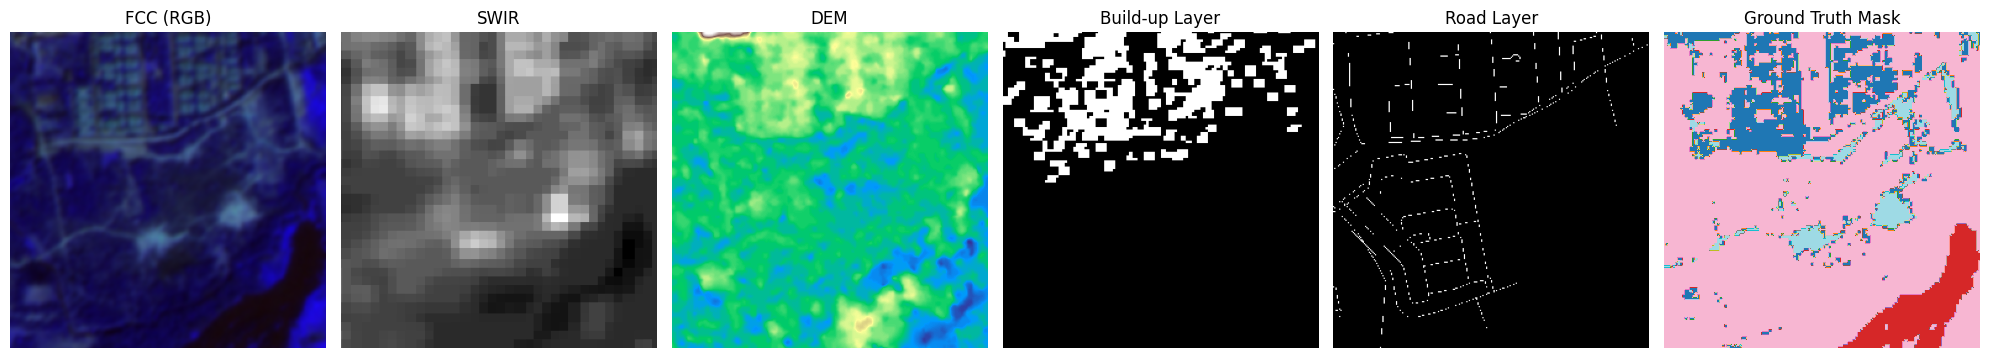

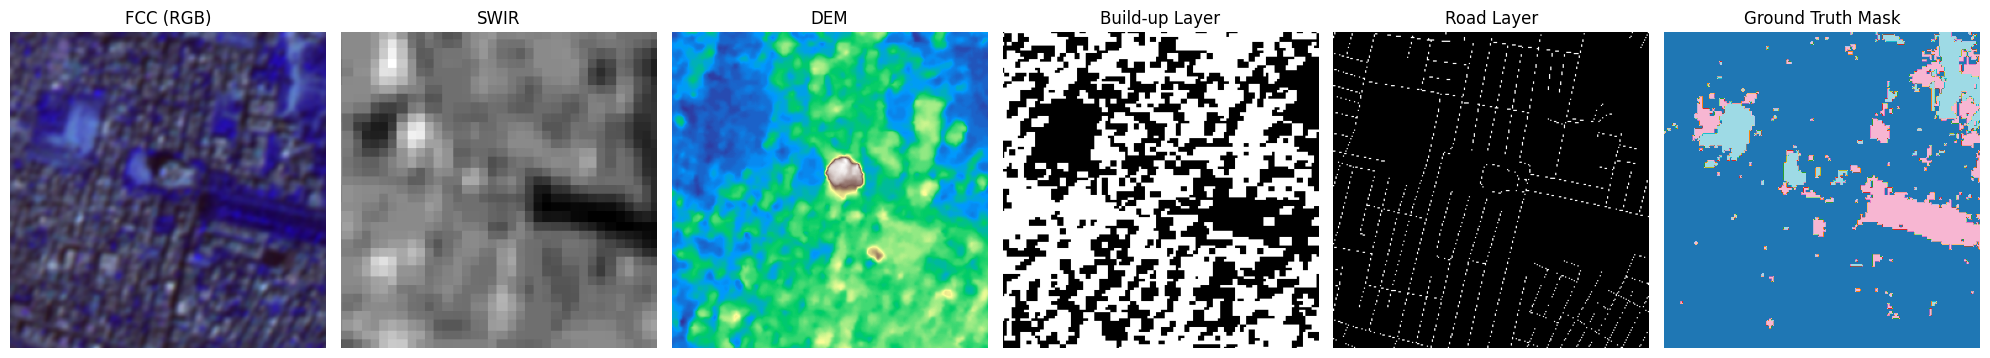

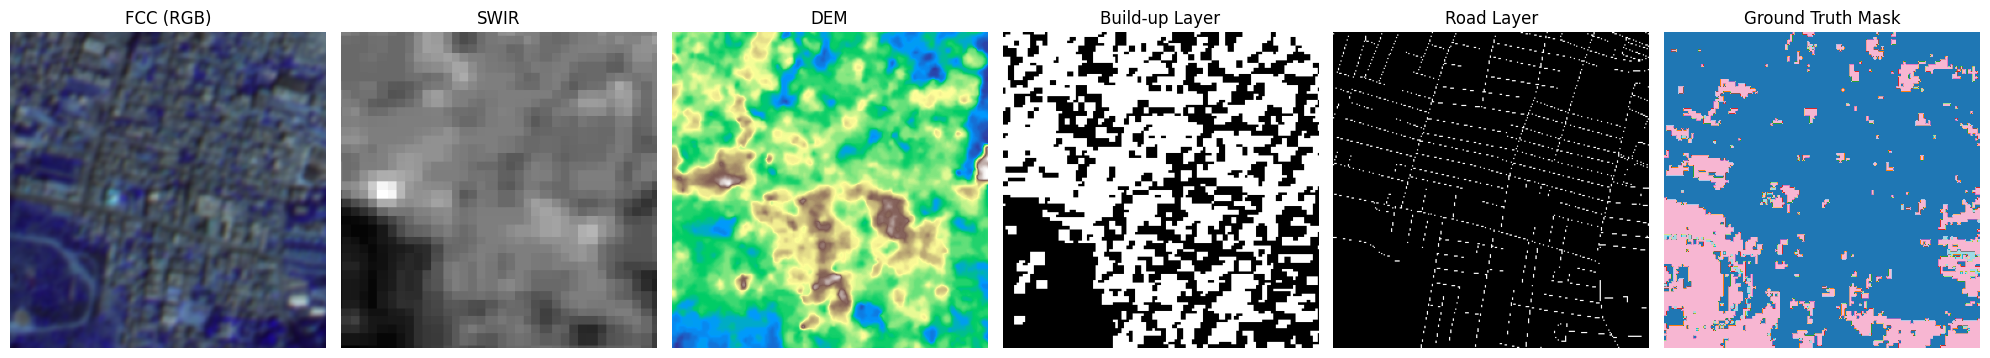

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Randomly visualize a few samples from your multimodal dataset
for i in range(3):
    # ----------------------------------------------------------
    # 1️⃣  Get random sample (fcc, swir, dem, build, road, mask)
    # ----------------------------------------------------------
    fcc, swir, dem, build, road, mask = train_dataset[np.random.randint(len(train_dataset))]

    # Convert to NumPy for visualization
    fcc_np   = fcc.numpy().transpose(1, 2, 0)    # [H, W, 3]
    swir_np  = swir.numpy().transpose(1, 2, 0)   # [H, W, C]
    dem_np   = dem.squeeze().numpy()             # [H, W]
    build_np = build.squeeze().numpy()           # [H, W]
    road_np = road.squeeze().numpy()             # [H, W]
    mask_np  = mask.numpy()                      # [H, W]

    # ----------------------------------------------------------
    # 2️⃣  Undo normalization for FCC (RGB)
    # ----------------------------------------------------------
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    fcc_vis = (fcc_np * std) + mean
    fcc_vis = np.clip(fcc_vis, 0, 1)

    # ----------------------------------------------------------
    # 3️⃣  Prepare SWIR visualization
    # ----------------------------------------------------------
    if swir_np.shape[2] > 1:
        swir_vis = swir_np[:, :, 0]  # Take first SWIR band
    else:
        swir_vis = swir_np.squeeze()

    # ----------------------------------------------------------
    # 4️⃣  Plot all modalities side-by-side
    # ----------------------------------------------------------
    plt.figure(figsize=(20, 5))

    # FCC (RGB)
    plt.subplot(1, 6, 1)
    plt.imshow(fcc_vis)
    plt.title("FCC (RGB)")
    plt.axis("off")

    # SWIR
    plt.subplot(1, 6, 2)
    plt.imshow(swir_vis, cmap="gray")
    plt.title("SWIR")
    plt.axis("off")

    # DEM
    plt.subplot(1, 6, 3)
    plt.imshow(dem_np, cmap="terrain")
    plt.title("DEM")
    plt.axis("off")

    # Build-up
    plt.subplot(1, 6, 4)
    plt.imshow(build_np, cmap="gray")
    plt.title("Build-up Layer")
    plt.axis("off")
    
    # ROAD
    plt.subplot(1, 6, 5)
    plt.imshow(road_np, cmap="gray")
    plt.title("Road Layer")
    plt.axis("off")

    # Mask
    plt.subplot(1, 6, 6)
    plt.imshow(mask_np, cmap="tab20")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


In [25]:
import torch
import numpy as np

# ==========================================================
# Pixel Accuracy
# ==========================================================
def pixel_accuracy(preds: torch.Tensor, labels: torch.Tensor) -> float:
    """
    Compute pixel-wise accuracy.
    Works for both single image and batched tensors.

    Args:
        preds:  [B, H, W] or [H, W] tensor of predicted class IDs
        labels: [B, H, W] or [H, W] tensor of ground truth class IDs
    Returns:
        float: overall pixel accuracy (0–1)
    """
    preds = preds.detach()
    labels = labels.detach()

    # Ensure shape compatibility
    assert preds.shape == labels.shape, f"Shape mismatch: {preds.shape} vs {labels.shape}"

    correct = (preds == labels).sum().item()
    total = labels.numel()
    return correct / total


# ==========================================================
# Mean IoU (mIoU)
# ==========================================================
def mean_iou(preds: torch.Tensor, labels: torch.Tensor, num_classes: int = 5):
    """
    Compute mean Intersection-over-Union (mIoU) and per-class IoU.

    Args:
        preds: [B, H, W] predicted class IDs
        labels: [B, H, W] ground truth class IDs
        num_classes: total number of segmentation classes

    Returns:
        tuple: (mean_iou, per_class_iou)
    """
    preds = preds.detach()
    labels = labels.detach()

    assert preds.shape == labels.shape, f"Shape mismatch: {preds.shape} vs {labels.shape}"

    ious = []
    for cls in range(num_classes):
        pred_mask = (preds == cls)
        label_mask = (labels == cls)

        intersection = torch.logical_and(pred_mask, label_mask).sum().item()
        union = torch.logical_or(pred_mask, label_mask).sum().item()

        if union == 0:
            ious.append(float("nan"))  # Class absent in batch
        else:
            ious.append(intersection / union)

    mean_iou_val = np.nanmean(ious)
    return mean_iou_val, ious


# ==========================================================
# 🔍 Example Usage for Validation or Debugging
# ==========================================================
def evaluate_sample(model, fcc, swir, dem, build, road, mask, num_classes=5, device='cuda'):
    """
    Run inference safely and compute metrics on a single batch or tile.
    """
    model.eval()
    with torch.no_grad():
        fcc   = fcc.to(device).float()
        swir  = swir.to(device).float()
        dem   = dem.to(device).float()
        build = build.to(device).float()
        road  = road.to(device).float()
        mask  = mask.to(device).long()

        # Forward pass
        logits = model(fcc, swir, dem, build)
        preds = torch.argmax(logits, dim=1)  # [B, H, W]

        # Compute metrics
        acc = pixel_accuracy(preds, mask)
        miou, per_class = mean_iou(preds, mask, num_classes=num_classes)

    print(f"✅ Pixel Accuracy: {acc:.4f}")
    print(f"✅ Mean IoU: {miou:.4f}")
    print(f"Per-class IoU: {[round(x, 4) if not np.isnan(x) else 'N/A' for x in per_class]}")
    return acc, miou, per_class


In [26]:
print(f"Train samples: {len(train_dataset)} ({len(train_loader)} batches of size {BATCH_SIZE})")
print(f"Val samples:   {len(val_dataset)} ({len(val_loader)} batches of size {BATCH_SIZE})")


Train samples: 3436 (3436 batches of size 1)
Val samples:   860 (860 batches of size 1)


New loss funtion: CE+Lovasz+tversky

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================
#                LOVASZ-SOFTMAX LOSS (FULL)
# ============================================================

def lovasz_grad(gt_sorted):
    """
    Computes gradient of the Lovasz extension w.r.t sorted errors.
    """
    gts = gt_sorted.sum()
    intersection = gts - gt_sorted.float().cumsum(0)
    union = gts + (1 - gt_sorted).float().cumsum(0)
    jaccard = 1.0 - intersection / union
    if len(jaccard) > 1:
        jaccard[1:] = jaccard[1:] - jaccard[:-1]
    return jaccard


def flatten_probas(probas, labels, ignore=None):
    """
    Flattens predictions from [B, C, H, W] → [P, C] and labels → [P].
    Removes ignored pixels.
    """
    if probas.dim() == 4:
        B, C, H, W = probas.size()
        probas = probas.permute(0, 2, 3, 1).contiguous().view(-1, C)
    labels = labels.view(-1)

    if ignore is not None:
        valid = labels != ignore
        probas = probas[valid]
        labels = labels[valid]

    return probas, labels


def lovasz_softmax(probas, labels, classes='present', ignore=255):
    """
    Multi-class Lovasz-Softmax loss.
    probas: [B, C, H, W] with softmax probabilities.
    labels: [B, H, W] with class indices.
    """
    probas, labels = flatten_probas(probas, labels, ignore)
    C = probas.size(1)

    losses = []
    for c in range(C):
        fg = (labels == c).float()

        if classes == 'present' and fg.sum() == 0:
            continue

        class_pred = probas[:, c]
        errors = (fg - class_pred).abs()

        errors_sorted, perm = torch.sort(errors, descending=True)
        fg_sorted = fg[perm]

        grad = lovasz_grad(fg_sorted)
        losses.append(torch.dot(errors_sorted, grad))

    if len(losses) == 0:
        return torch.tensor(0.0, device=probas.device)

    return sum(losses) / len(losses)


# ============================================================
#                Tversky LOSS
# ============================================================

def tversky_loss(preds, targets, alpha=0.3, beta=0.7, eps=1e-6, ignore_index=255):
    """
    preds: [B, C, H, W] (softmax probabilities)
    targets: [B, H, W] integer labels
    """
    num_classes = preds.shape[1]

    # mask ignore_index
    valid = (targets != ignore_index)
    preds = preds * valid.unsqueeze(1)

    # one-hot encode
    targets_1hot = torch.zeros_like(preds)
    targets_1hot.scatter_(1, targets.unsqueeze(1), 1)
    targets_1hot = targets_1hot * valid.unsqueeze(1)

    tp = (preds * targets_1hot).sum(dim=(0, 2, 3))
    fp = (preds * (1 - targets_1hot)).sum(dim=(0, 2, 3))
    fn = ((1 - preds) * targets_1hot).sum(dim=(0, 2, 3))

    tversky = (tp + eps) / (tp + alpha * fn + beta * fp + eps)
    return 1.0 - tversky.mean()


# ============================================================
#       COMBINED LOSS: CE + LOVASZ + TVERSKY
# ============================================================

class CELovaszTverskyLoss(nn.Module):
    def __init__(self,
                 ce_ratio=0.6,          # Weight for CrossEntropy
                 lovasz_ratio=0.2,      # Weight for Lovasz
                 tversky_ratio=0.2,     # Weight for Tversky
                 weight=None,           # CE class weights
                 alpha=0.3, beta=0.7,   # Tversky params
                 ignore_index=255):

        super().__init__()

        self.ce = nn.CrossEntropyLoss(weight=weight, ignore_index=ignore_index)

        self.ce_ratio = ce_ratio
        self.lovasz_ratio = lovasz_ratio
        self.tversky_ratio = tversky_ratio

        self.alpha = alpha
        self.beta = beta
        self.ignore_index = ignore_index

    def forward(self, preds, targets):
        # Cross-Entropy
        ce_loss = self.ce(preds, targets)

        # Lovasz softmax on probabilities
        probs = torch.softmax(preds, dim=1)
        lovasz_loss = lovasz_softmax(probs, targets, ignore=self.ignore_index)

        # Tversky
        tversky = tversky_loss(
            preds=probs,
            targets=targets,
            alpha=self.alpha,
            beta=self.beta,
            ignore_index=self.ignore_index
        )

        # Combined
        total = (
            self.ce_ratio * ce_loss +
            self.lovasz_ratio * lovasz_loss +
            self.tversky_ratio * tversky
        )

        return total


In [28]:
batch = next(iter(train_loader))
print(len(batch))
for i, b in enumerate(batch):
    print(f"Item {i} shape:", b.shape)


6
Item 0 shape: torch.Size([1, 3, 256, 256])
Item 1 shape: torch.Size([1, 3, 256, 256])
Item 2 shape: torch.Size([1, 1, 256, 256])
Item 3 shape: torch.Size([1, 1, 256, 256])
Item 4 shape: torch.Size([1, 1, 256, 256])
Item 5 shape: torch.Size([1, 256, 256])


In [31]:
batch = next(iter(train_loader))
print(len(batch))   # must print 6


6


Training loop

In [32]:
import torch
import numpy as np
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

# ==========================================================
# Helper: Update Confusion Matrix
# ==========================================================
def update_confusion_matrix(cm, preds, labels, num_classes):
    preds = preds.cpu().numpy().ravel()
    labels = labels.cpu().numpy().ravel()
    cm += confusion_matrix(labels, preds, labels=list(range(num_classes)))
    return cm


# ==========================================================
# Pixel Correction Scheduler (controls % of corrected pixels)
# ==========================================================
def get_allowed_ratio(epoch, warmup, max_ratio):
    if epoch < warmup:
        return 0.0

    # linear ramp from 0 → max_ratio
    return min(max_ratio, max_ratio * (epoch - warmup) / (warmup))


# ==========================================================
# SETTINGS
# ==========================================================
num_classes = 5
criterion = CELovaszTverskyLoss(ce_ratio=0.5, ignore_index=255)

scaler = torch.amp.GradScaler("cuda")

train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_ious, val_ious = [], []
all_train_cms, all_val_cms = [], []

# ------------------------
# CONFIDENCE THRESHOLDING
# ------------------------
USE_CONFIDENCE = True
CONF_THRESHOLD = 0.92
MIN_THRESHOLD = 0.60
MAX_THRESHOLD = 0.97

# ------------------------
# CORRECTION CONTROL
# ------------------------
WARMUP_EPOCHS = 5
MAX_CORR_RATIO = 0.15                # at most 10% pixels in batch may be corrected
epoch_corrected_pixels = []


# ==========================================================
# TRAINING LOOP
# ==========================================================
for epoch in range(1, num_epochs + 1):

    # ------------------------ TRAIN -------------------------
    model.train()

    tr_loss = tr_acc = tr_iou = 0.0
    train_cm = np.zeros((num_classes, num_classes), dtype=np.int64)

    corrected_this_epoch = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} [Training]", leave=False)

    for batch_idx, (fcc, swir, dem, build, road, masks) in enumerate(pbar):

        fcc, swir, dem, build, road, masks = (
            fcc.to(device).float(),
            swir.to(device).float(),
            dem.to(device).float(),
            build.to(device).float(),
            road.to(device).float(),
            masks.to(device).long()
        )

        optimizer.zero_grad(set_to_none=True)

        try:
            with torch.amp.autocast("cuda", dtype=torch.float16):

                logits = model(fcc, swir, dem, build, road)
                preds = torch.argmax(logits.detach(), dim=1)

                # --------- METRICS ----------
                tr_acc += pixel_accuracy(preds.cpu(), masks.cpu())
                miou, _ = mean_iou(preds.cpu(), masks.cpu(), num_classes)
                tr_iou += miou
                train_cm = update_confusion_matrix(train_cm, preds.cpu(), masks.cpu(), num_classes)

                # ==========================================================
                # PIXEL CORRECTION (AFTER WARMUP) — controlled & safe
                # ==========================================================
                masks_corrected = masks.clone()

                incorrect = (preds != masks)

                if USE_CONFIDENCE:
                    probs = torch.softmax(logits, dim=1)
                    conf = probs.max(dim=1)[0]
                    incorrect_conf = incorrect & (conf > CONF_THRESHOLD)
                else:
                    incorrect_conf = incorrect

                # How many pixels are eligible
                eligible_idx = incorrect_conf.nonzero(as_tuple=True)
                eligible_count = len(eligible_idx[0])

                # Allowed correction count for this epoch
                batch_pixels = masks.numel()
                allowed_ratio = get_allowed_ratio(epoch, WARMUP_EPOCHS, MAX_CORR_RATIO)
                allowed_pixels = int(batch_pixels * allowed_ratio)

                if allowed_pixels > 0 and eligible_count > 0:
                    # Limit the number of corrected pixels
                    if eligible_count > allowed_pixels:
                        chosen = torch.randperm(eligible_count)[:allowed_pixels]
                        chosen_idx = (eligible_idx[0][chosen], eligible_idx[1][chosen], eligible_idx[2][chosen])
                    else:
                        chosen_idx = eligible_idx

                    # Apply correction
                    masks_corrected[chosen_idx] = preds[chosen_idx]
                    corrected_this_epoch += len(chosen_idx[0])

                # ==========================================================
                # Compute loss with corrected masks (only after warmup)
                # ==========================================================
                if epoch >= WARMUP_EPOCHS:
                    loss = criterion(logits, masks_corrected)
                else:
                    loss = criterion(logits, masks)

            # Backprop
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            tr_loss += loss.item()

            pbar.set_postfix({
                "Loss": f"{tr_loss/(batch_idx+1):.4f}",
                "Acc": f"{(tr_acc/(batch_idx+1))*100:.2f}%",
                "mIoU": f"{tr_iou/(batch_idx+1):.4f}",
                "corr": corrected_this_epoch
            })

        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                pbar.write(f"⚠️ Skipping batch {batch_idx} (OOM)")
                continue
            else:
                raise e

    # END TRAIN
    tr_loss /= len(train_loader)
    tr_acc  /= len(train_loader)
    tr_iou  /= len(train_loader)

    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    train_ious.append(tr_iou)
    all_train_cms.append(train_cm.copy())

    epoch_corrected_pixels.append(corrected_this_epoch)


    # ------------------------ VALIDATION -------------------------
    model.eval()
    va_loss = va_acc = va_iou = 0.0
    val_cm = np.zeros((num_classes, num_classes), dtype=np.int64)

    vbar = tqdm(val_loader, desc=f"Epoch {epoch}/{num_epochs} [Validation]", leave=False)

    with torch.no_grad():

        for batch_idx, (fcc, swir, dem, build, road, masks) in enumerate(vbar):

            fcc, swir, dem, build, road, masks = (
                fcc.to(device).float(),
                swir.to(device).float(),
                dem.to(device).float(),
                build.to(device).float(),
                road.to(device).float(),
                masks.to(device).long()
            )

            with torch.amp.autocast("cuda", dtype=torch.float16):
                logits = model(fcc, swir, dem, build, road)
                loss = criterion(logits, masks)

            preds_cpu = torch.argmax(logits, dim=1).cpu()
            masks_cpu = masks.cpu()

            va_loss += loss.item()
            va_acc  += pixel_accuracy(preds_cpu, masks_cpu)
            miou, _ = mean_iou(preds_cpu, masks_cpu, num_classes)
            va_iou += miou

            val_cm = update_confusion_matrix(val_cm, preds_cpu, masks_cpu, num_classes)

    # END VALIDATION
    va_loss /= len(val_loader)
    va_acc  /= len(val_loader)
    va_iou  /= len(val_loader)

    val_losses.append(va_loss)
    val_accs.append(va_acc)
    val_ious.append(va_iou)
    all_val_cms.append(val_cm.copy())

    tqdm.write(
        f"📘 Epoch {epoch}/{num_epochs} | "
        f"Train Loss: {tr_loss:.4f} | Val Loss: {va_loss:.4f} | "
        f"Train Acc: {tr_acc*100:.2f}% | Val Acc: {va_acc*100:.2f}% | "
        f"Train mIoU: {tr_iou:.4f} | Val mIoU: {va_iou:.4f} | "
        f"Corrected: {corrected_this_epoch}"
    )

    # ==========================================================
    # ADAPTIVE CONFIDENCE THRESHOLD
    # ==========================================================
    new_thresh = CONF_THRESHOLD + (va_iou - 0.5) * 0.02
    new_thresh = max(MIN_THRESHOLD, min(MAX_THRESHOLD, new_thresh))

    tqdm.write(f"🔧 CONF_THRESHOLD: {CONF_THRESHOLD:.3f} → {new_thresh:.3f}")
    CONF_THRESHOLD = new_thresh


# Print per-epoch corrected pixels
print("\n=== Corrected Pixels Per Epoch ===")
for e, cp in enumerate(epoch_corrected_pixels, 1):
    print(f"Epoch {e}: {cp} pixels")


📘 Epoch 1/20 | Train Loss: 0.4163 | Val Loss: 0.4072 | Train Acc: 84.57% | Val Acc: 84.42% | Train mIoU: 0.5128 | Val mIoU: 0.5261 | Corrected: 0
🔧 CONF_THRESHOLD: 0.920 → 0.921


📘 Epoch 2/20 | Train Loss: 0.3764 | Val Loss: 0.3921 | Train Acc: 86.61% | Val Acc: 85.05% | Train mIoU: 0.5531 | Val mIoU: 0.5627 | Corrected: 0
🔧 CONF_THRESHOLD: 0.921 → 0.922


📘 Epoch 3/20 | Train Loss: 0.3651 | Val Loss: 0.3892 | Train Acc: 87.14% | Val Acc: 85.61% | Train mIoU: 0.5624 | Val mIoU: 0.5572 | Corrected: 0
🔧 CONF_THRESHOLD: 0.922 → 0.923


📘 Epoch 4/20 | Train Loss: 0.3560 | Val Loss: 0.3851 | Train Acc: 87.53% | Val Acc: 85.55% | Train mIoU: 0.5715 | Val mIoU: 0.5495 | Corrected: 0
🔧 CONF_THRESHOLD: 0.923 → 0.924


📘 Epoch 5/20 | Train Loss: 0.3491 | Val Loss: 0.3614 | Train Acc: 87.82% | Val Acc: 86.02% | Train mIoU: 0.5799 | Val mIoU: 0.5711 | Corrected: 0
🔧 CONF_THRESHOLD: 0.924 → 0.925


...

📘 Epoch 16/20 | Train Loss: 0.2138 | Val Loss: 0.3498 | Train Acc: 89.41% | Val Acc: 86.51% | Train mIoU: 0.6295 | Val mIoU: 0.5851 | Corrected: 5406909
🔧 CONF_THRESHOLD: 0.941 → 0.943


📘 Epoch 17/20 | Train Loss: 0.2141 | Val Loss: 0.3359 | Train Acc: 89.51% | Val Acc: 87.38% | Train mIoU: 0.6310 | Val mIoU: 0.5884 | Corrected: 5228122
🔧 CONF_THRESHOLD: 0.943 → 0.944


📘 Epoch 18/20 | Train Loss: 0.2159 | Val Loss: 0.3505 | Train Acc: 89.50% | Val Acc: 87.59% | Train mIoU: 0.6327 | Val mIoU: 0.5979 | Corrected: 5024567
🔧 CONF_THRESHOLD: 0.944 → 0.946


📘 Epoch 19/20 | Train Loss: 0.2154 | Val Loss: 0.3518 | Train Acc: 89.61% | Val Acc: 86.70% | Train mIoU: 0.6366 | Val mIoU: 0.5880 | Corrected: 4763306
🔧 CONF_THRESHOLD: 0.946 → 0.948


📘 Epoch 20/20 | Train Loss: 0.2166 | Val Loss: 0.3653 | Train Acc: 89.65% | Val Acc: 87.16% | Train mIoU: 0.6381 | Val mIoU: 0.5892 | Corrected: 4567854
🔧 CONF_THRESHOLD: 0.948 → 0.950

=== Corrected Pixels Per Epoch ===
Epoch 1: 0 pixels
Epoch 2: 0 pixels
Epoch 3: 0 pixels
Epoch 4: 0 pixels
Epoch 5: 0 pixels
Epoch 6: 4285656 pixels
Epoch 7: 6181472 pixels
Epoch 8: 6721301 pixels
Epoch 9: 6818901 pixels
Epoch 10: 6667395 pixels
Epoch 11: 6481398 pixels
Epoch 12: 6264998 pixels
Epoch 13: 6096477 pixels
Epoch 14: 5849767 pixels
Epoch 15: 5679134 pixels
Epoch 16: 5406909 pixels
Epoch 17: 5228122 pixels
Epoch 18: 5024567 pixels
Epoch 19: 4763306 pixels
Epoch 20: 4567854 pixels


Plot saved at: D:/Vikash/output/training curves.png


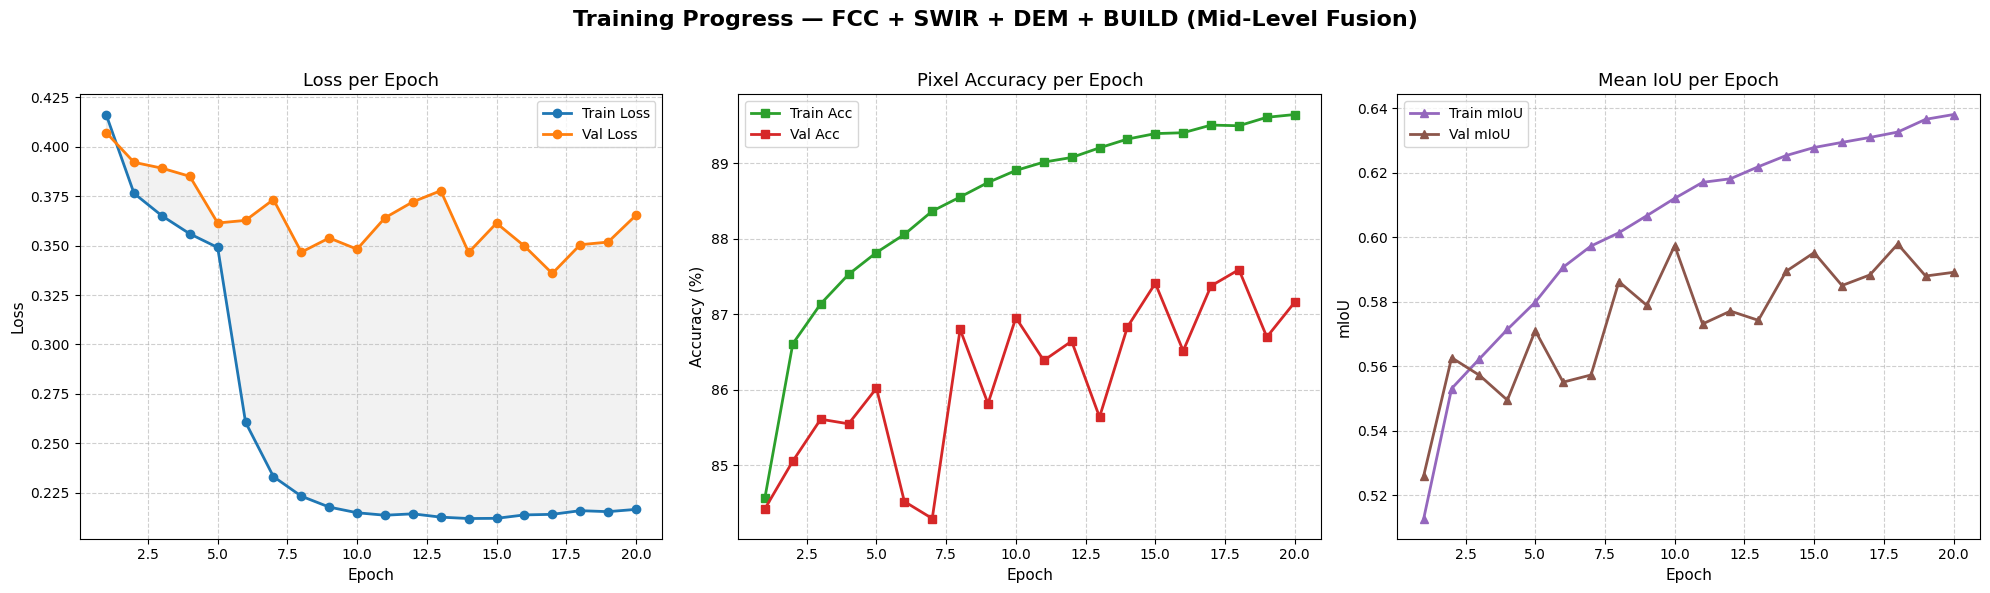

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import os

# -----------------------------------------
# Enhanced Plot: Training and Validation Curves
# -----------------------------------------

# ----- Set save path -----
save_path = r"D:/Vikash/output/training curves.png"    # change this path
os.makedirs(os.path.dirname(save_path), exist_ok=True)

epochs = np.arange(1, len(train_losses) + 1)

plt.figure(figsize=(20, 6))
plt.suptitle(
    "Training Progress — FCC + SWIR + DEM + BUILD (Mid-Level Fusion)",
    fontsize=16,
    fontweight='bold'
)

# ===== Loss Curve =====
plt.subplot(1, 3, 1)
plt.plot(epochs, train_losses, label="Train Loss", color="#1f77b4", linewidth=2, marker='o')
plt.plot(epochs, val_losses, label="Val Loss", color="#ff7f0e", linewidth=2, marker='o')
plt.fill_between(epochs, train_losses, val_losses, color="gray", alpha=0.1)
plt.title("Loss per Epoch", fontsize=13)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Loss", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# ===== Pixel Accuracy Curve =====
plt.subplot(1, 3, 2)
plt.plot(epochs, [a * 100 for a in train_accs], label="Train Acc", color="#2ca02c", linewidth=2, marker='s')
plt.plot(epochs, [a * 100 for a in val_accs], label="Val Acc", color="#d62728", linewidth=2, marker='s')
plt.title("Pixel Accuracy per Epoch", fontsize=13)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Accuracy (%)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# ===== Mean IoU Curve =====
plt.subplot(1, 3, 3)
plt.plot(epochs, train_ious, label="Train mIoU", color="#9467bd", linewidth=2, marker='^')
plt.plot(epochs, val_ious, label="Val mIoU", color="#8c564b", linewidth=2, marker='^')
plt.title("Mean IoU per Epoch", fontsize=13)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("mIoU", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])

# ----- Save plot -----
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Plot saved at: {save_path}")

# ----- Show plot -----
plt.show()


Calling the trained model

✅ Saved confusion matrix to: D:/Vikash/output/confusion.png\Training_Confusion_Matrix.png


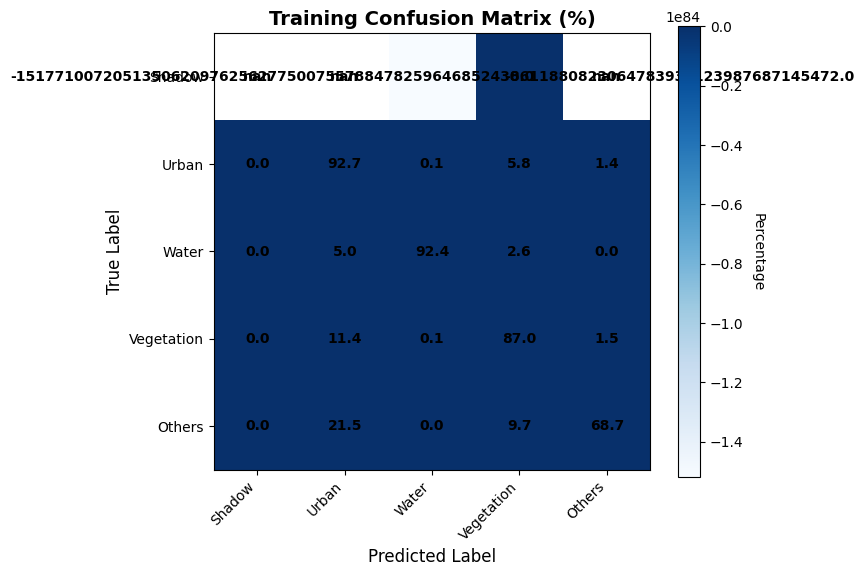

✅ Saved confusion matrix to: D:/Vikash/output/confusion.png\Validation_Confusion_Matrix.png


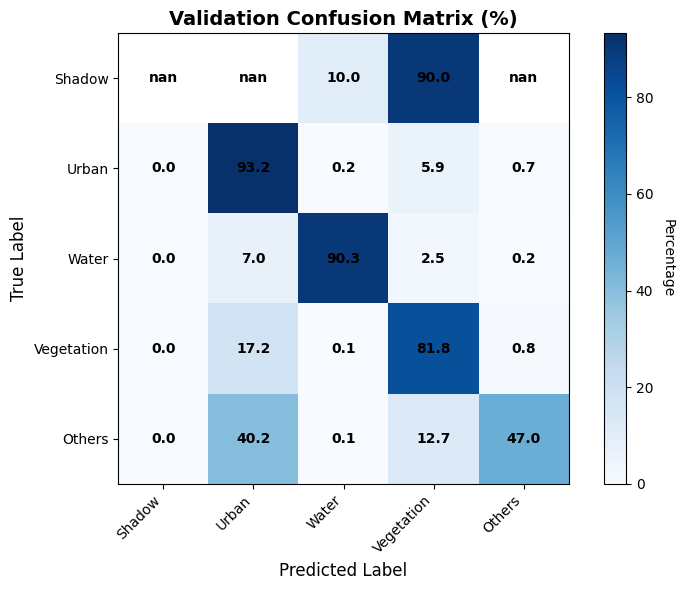

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix", normalize=True, figsize=(8, 6), save_dir=None):
    """
    Plots and saves a confusion matrix.

    Args:
        cm (np.ndarray): Confusion matrix [num_classes, num_classes].
        class_names (list): Class names.
        title (str): Plot title.
        normalize (bool): Normalize values to percentages.
        figsize (tuple): Figure size.
        save_dir (str): Directory to save the plot.
    """

    cm = np.array(cm, dtype=np.float64)

    # Normalize rows to % (optional)
    if normalize:
        cm_sum = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm, cm_sum, where=cm_sum != 0) * 100

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")

    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Percentage" if normalize else "Count", rotation=270, labelpad=15)

    # Axis ticks
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    # Labels
    ax.set_title(f"{title} ({'%' if normalize else 'Counts'})", fontsize=14, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)

    # Annotate each cell
    fmt = ".1f" if normalize else "d"
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], fmt),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=10, fontweight="bold"
            )

    plt.tight_layout()

    # --- Save to directory ---
    if save_dir is None:
        save_dir = "D:/Vikash/output/confusion.png"  # default path

    os.makedirs(save_dir, exist_ok=True)

    save_path = os.path.join(
        save_dir,
        f"{title.replace(' ', '_').replace('%', '')}.png"   # clean file name
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"✅ Saved confusion matrix to: {save_path}")

    plt.show()


# -----------------------------
# Example usage
# -----------------------------
class_names = ["Shadow", "Urban", "Water", "Vegetation", "Others"]

# Example CM (replace with your real matrices)
# train_cm = np.array([...])
# val_cm = np.array([...])

plot_confusion_matrix(train_cm, class_names, title="Training Confusion Matrix", normalize=True)
plot_confusion_matrix(val_cm, class_names, title="Validation Confusion Matrix", normalize=True)

# To save raw counts:
# plot_confusion_matrix(val_cm, class_names, title="Validation CM Counts", normalize=False)


Saved: D:/Vikash/output/index47.png\inference_result_47.png


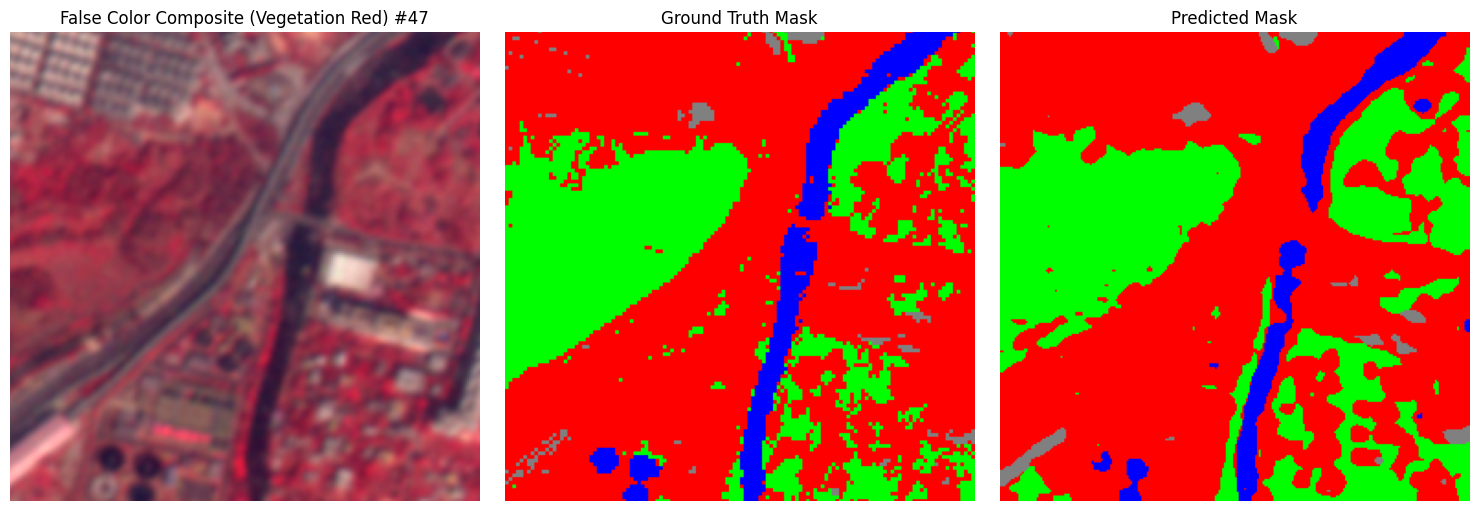

Saved: D:/Vikash/output/index47.png\dem_47.png


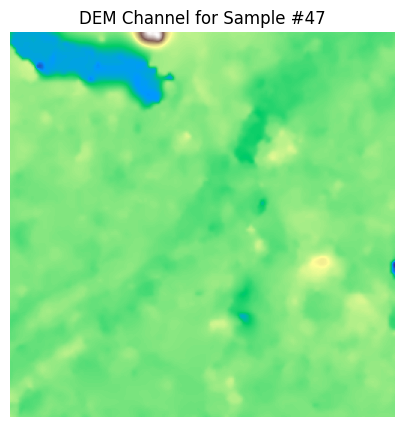

Saved: D:/Vikash/output/index47.png\build_47.png


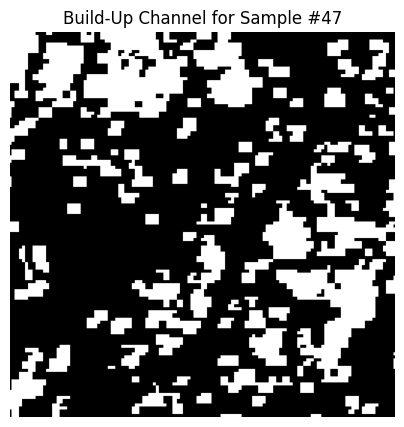

Saved: D:/Vikash/output/index47.png\swir_47_channel_1.png


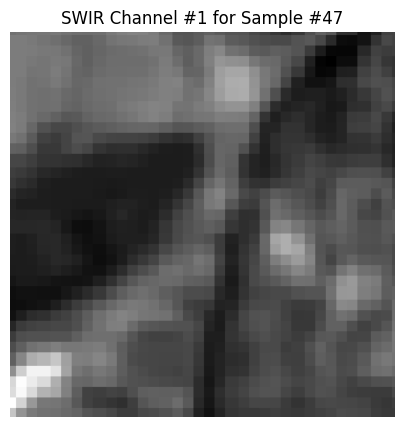

Saved: D:/Vikash/output/index47.png\swir_47_channel_2.png


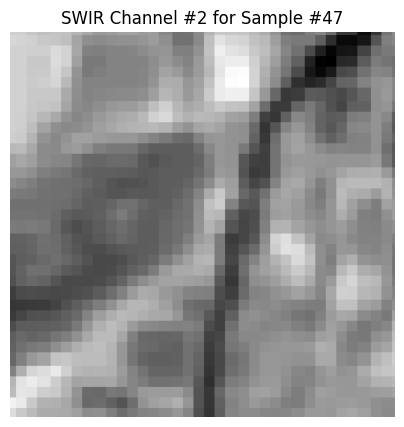

Saved: D:/Vikash/output/index47.png\swir_47_channel_3.png


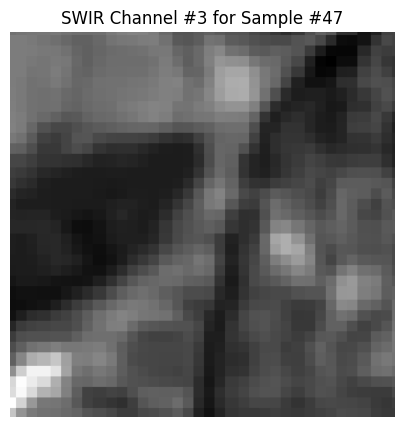

Saved: D:/Vikash/output/index47.png\road_47_channel_1.png


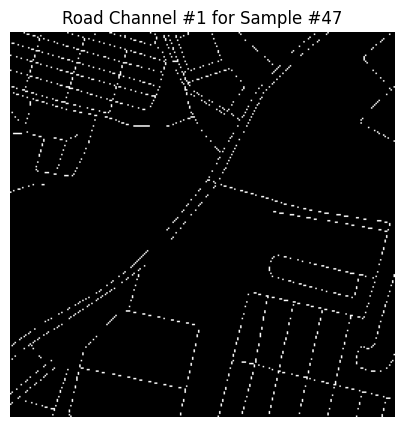

FCC shape: (3, 256, 256), SWIR: torch.Size([3, 256, 256]), DEM: torch.Size([1, 256, 256]), BUILD: torch.Size([1, 256, 256]), ROAD: torch.Size([1, 256, 256])


In [35]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import os

# ======================================
# Save directory
# ======================================
SAVE_DIR = r"D:/Vikash/output/index47.png"
os.makedirs(SAVE_DIR, exist_ok=True)

# ======================================
# Color Map for 5 Classes
# ======================================
COLOR_MAP = {
    0: (255, 255,   0),   # Shadow / Barren -> Yellow
    1: (255,   0,   0),   # Urban  -> Red
    2: (  0,   0, 255),   # Water  -> Blue
    3: (  0, 255,   0),   # Vegetation -> Green
    4: (128, 128, 128)    # Others -> Gray
}

def decode_color(mask_np):
    """Convert class indices to RGB image using COLOR_MAP."""
    h, w = mask_np.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for cls, color in COLOR_MAP.items():
        rgb[mask_np == cls] = color
    return rgb

# ======================================
# Inference on a Validation Sample
# ======================================
model.eval()
idx = 47  # Choose any sample index

# Fetch sample (FCC, SWIR, DEM, BUILD, ROAD, MASK)
fcc, swir, dem, build, road, true_mask = val_dataset[idx]

# Add batch dimension and move to device
fcc_batch   = fcc.unsqueeze(0).to(device)
swir_batch  = swir.unsqueeze(0).to(device)
dem_batch   = dem.unsqueeze(0).to(device)
build_batch = build.unsqueeze(0).to(device)
road_batch  = road.unsqueeze(0).to(device)

# Forward pass
with torch.no_grad():
    outputs = model(fcc_batch, swir_batch, dem_batch, build_batch, road_batch)
    pred_mask = torch.argmax(outputs, dim=1).squeeze(0).cpu().numpy()

# ======================================
# Prepare FCC RGB for visualization
# ======================================
fcc_np = fcc.cpu().numpy()
true_mask_np = true_mask.cpu().numpy()

mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
std  = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)

img_rgb = (fcc_np[:3] * std + mean)
img_rgb = np.clip(img_rgb * 1.3, 0, 1)  # brighten
gamma = 0.8
img_rgb = np.power(img_rgb, gamma)
img_rgb = img_rgb[[2, 1, 0], :, :]       # FCC enhancement
img_rgb = np.transpose(img_rgb, (1, 2, 0))

# ======================================
# Plot FCC + GT + Prediction
# ======================================
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title(f"False Color Composite (Vegetation Red) #{idx}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(decode_color(true_mask_np))
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(decode_color(pred_mask))
plt.title("Predicted Mask")
plt.axis("off")

plt.tight_layout()
save_main = os.path.join(SAVE_DIR, f"inference_result_{idx}.png")
plt.savefig(save_main, dpi=300, bbox_inches="tight")
print(f"Saved: {save_main}")
plt.show()

# ======================================
# DEM Visualization
# ======================================
plt.figure(figsize=(5, 5))
plt.imshow(dem.squeeze().cpu(), cmap='terrain')
plt.title(f"DEM Channel for Sample #{idx}")
plt.axis("off")
save_dem = os.path.join(SAVE_DIR, f"dem_{idx}.png")
plt.savefig(save_dem, dpi=300, bbox_inches="tight")
print(f"Saved: {save_dem}")
plt.show()

# ======================================
# BUILD Visualization
# ======================================
plt.figure(figsize=(5, 5))
plt.imshow(build.squeeze().cpu(), cmap='gray')
plt.title(f"Build-Up Channel for Sample #{idx}")
plt.axis("off")
save_build = os.path.join(SAVE_DIR, f"build_{idx}.png")
plt.savefig(save_build, dpi=300, bbox_inches="tight")
print(f"Saved: {save_build}")
plt.show()

# ======================================
# SWIR Channels Visualization
# ======================================
for j in range(swir.shape[0]):
    plt.figure(figsize=(5, 5))
    plt.imshow(swir[j].cpu(), cmap='gray')
    plt.title(f"SWIR Channel #{j+1} for Sample #{idx}")
    plt.axis("off")

    save_swir = os.path.join(SAVE_DIR, f"swir_{idx}_channel_{j+1}.png")
    plt.savefig(save_swir, dpi=300, bbox_inches="tight")
    print(f"Saved: {save_swir}")
    plt.show()

# ======================================
# Road Channels Visualization
# ======================================
for j in range(road.shape[0]):
    plt.figure(figsize=(5, 5))
    plt.imshow(road[j].cpu(), cmap='gray')
    plt.title(f"Road Channel #{j+1} for Sample #{idx}")
    plt.axis("off")

    save_road = os.path.join(SAVE_DIR, f"road_{idx}_channel_{j+1}.png")
    plt.savefig(save_road, dpi=300, bbox_inches="tight")
    print(f"Saved: {save_road}")
    plt.show()

# ======================================
# Summary
# ======================================
print(f"FCC shape: {fcc_np.shape}, SWIR: {swir.shape}, DEM: {dem.shape}, BUILD: {build.shape}, ROAD: {road.shape}")


In [36]:
save_dir = "D:/Vikash/output/20E_15%_pseudo"

import os
import torch
os.makedirs(save_dir, exist_ok=True)

# Save trained model state dictionary
torch.save(model.state_dict(), os.path.join(save_dir, 'model_state_dict_20E.pth'))

# The custom model doesn't have a save_pretrained method for the processor.
# If you were using the Hugging Face SegformerForSemanticSegmentation, you would save the processor like this:
# processor.save_pretrained(save_dir)

print(f"✅ Model state dictionary saved to {os.path.join(save_dir, 'model_state_dict_20E.pth')}")

✅ Model state dictionary saved to D:/Vikash/output/20E_15%_pseudo\model_state_dict_20E.pth
